## 6a. All subjects session average statistical testing

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_ROOT = "../../../Data/"
df_export = pd.read_csv("../../../Results/Tessnim/all_subjects_yeo7_metrics.csv")

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]


all_data = {}

# group by subject / session / run / network and average over parcels
grouped = df_export.groupby(["subject", "session", "run", "network"])

# container: subject -> session -> run -> arrays (7,)
tmp = {}

for (sid, sess_id, run_key, net_id), g in grouped:
    tmp.setdefault(sid, {}).setdefault(sess_id, {}).setdefault(run_key, {
        "condition": g["condition"].iloc[0],
        "segregation": np.full(7, np.nan),
        "integration": np.full(7, np.nan),
        "normalized_segregation": np.full(7, np.nan),
    })
    idx = int(net_id) - 1
    tmp[sid][sess_id][run_key]["segregation"][idx] = g["segregation"].mean()
    tmp[sid][sess_id][run_key]["integration"][idx] = g["integration"].mean()
    tmp[sid][sess_id][run_key]["normalized_segregation"][idx] = g["normalized_segregation"].mean()

# wrap into the all_data structure expected by your plotting code
for sid, sess_dict in tmp.items():
    subj = all_data.setdefault(sid, {"sessions": {}})
    for sess_id, run_dict in sess_dict.items():
        sess_runs = subj["sessions"].setdefault(sess_id, {})
        for run_key, rd in run_dict.items():
            sess_runs[run_key] = rd

In [3]:
def collect_rows(all_data, condition_filter=None):
    """
    Build a list of row-dicts from all subjects.
    Each row: subject, session, run, condition, segregation (7,), integration (7,),
              normalized_segregation (7,).

    condition_filter : str or None  – keep only this condition if given
    """
    all_rows = {}
    for sid, subj in all_data.items():
        rows = []
        for sess_id, sess_runs in subj["sessions"].items():
            for run_key in sorted(sess_runs.keys(), key=lambda x: int(x.replace("Run", ""))):
                rd = sess_runs[run_key]
                if condition_filter and rd["condition"] != condition_filter:
                    continue
                rows.append({
                    "subject":               sid,
                    "session":               sess_id,
                    "run":                   run_key,
                    "label":                 f"{sess_id}_{run_key}",
                    "condition":             rd["condition"],
                    "segregation":           rd["segregation"],
                    "integration":           rd["integration"],
                    "normalized_segregation": rd["normalized_segregation"],
                })
        all_rows[sid] = rows
    return all_rows


In [4]:
# Use the group-average session values computed the same way as the plots
# Recompute them here cleanly for all conditions
subject_rows = collect_rows(all_data)
all_sessions_set = set()
for rows in subject_rows.values():
    for r in rows:
        all_sessions_set.add(r["session"])
all_sessions = sorted(all_sessions_set)

def session_avg_for_subject(rows, all_sessions):
    session_groups = defaultdict(list)
    for r in rows:
        session_groups[r["session"]].append(r)
    seg_sv, int_sv, normseg_sv = [], [], []
    for sess in all_sessions:
        sess_rows = session_groups.get(sess, [])
        if sess_rows:
            seg_sv.append(np.nanmean(np.vstack([r["segregation"] for r in sess_rows]), axis=0))
            int_sv.append(np.nanmean(np.vstack([r["integration"] for r in sess_rows]), axis=0))
            normseg_sv.append(np.nanmean(np.vstack([r["normalized_segregation"] for r in sess_rows]), axis=0))
        else:
            seg_sv.append(np.full(7, np.nan))
            int_sv.append(np.full(7, np.nan))
            normseg_sv.append(np.full(7, np.nan))
    return np.vstack(seg_sv), np.vstack(int_sv), np.vstack(normseg_sv)

per_subject = {sid: session_avg_for_subject(rows, all_sessions)
               for sid, rows in subject_rows.items() if rows}

seg_group     = np.nanmean(np.stack([v[0] for v in per_subject.values()]), axis=0)  # n_sessions x 7
int_group     = np.nanmean(np.stack([v[1] for v in per_subject.values()]), axis=0)
normseg_group = np.nanmean(np.stack([v[2] for v in per_subject.values()]), axis=0)

x = np.arange(len(all_sessions))  # session index as the "time" variable

print(f"{'Network':<20} {'Seg ρ':>8} {'Seg p':>10} {'Int ρ':>8} {'Int p':>10} {'NormSeg ρ':>10} {'NormSeg p':>10}")
print("-" * 80)
for i, net in enumerate(YEO_NAMES):
    rho_seg,    p_seg    = spearmanr(x, seg_group[:, i])
    rho_int,    p_int    = spearmanr(x, int_group[:, i])
    rho_nrm,    p_nrm    = spearmanr(x, normseg_group[:, i])
    def sig_stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""
    def fmt_p(p):
        stars = sig_stars(p)
        return f"{p:6.3f}{stars:<3}"  # stars left-aligned in a 3-char slot


    print(f"{net:<20} {rho_seg:>+8.3f} {fmt_p(p_seg)}  {rho_int:>+8.3f} {fmt_p(p_int)}  {rho_nrm:>+8.3f} {fmt_p(p_nrm)}")



Network                 Seg ρ      Seg p    Int ρ      Int p  NormSeg ρ  NormSeg p
--------------------------------------------------------------------------------
Visual                 -0.704  0.003**     -0.625  0.013*      +0.582  0.023*  
Somatomotor            -0.514  0.050*      -0.661  0.007**     +0.796  0.000***
Dorsal Attention       -0.768  0.001***    -0.693  0.004**     +0.589  0.021*  
Ventral Attention      -0.814  0.000***    -0.764  0.001***    +0.796  0.000***
Limbic                 +0.061  0.830       -0.564  0.028*      +0.864  0.000***
Frontoparietal         -0.711  0.003**     -0.771  0.001***    +0.725  0.002** 
Default                -0.579  0.024*      -0.675  0.006**     +0.886  0.000***


In [5]:
def p_to_stars(p):
    if np.isnan(p): return ""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

## 6b. Per subject session average testing

In this section, we test whether each subject shows a **monotonic change across sessions** in the network-level metrics.

**What we do:**

- For each **subject**, we use the precomputed matrices `per_subject`, which contain:
  - `seg_sess`, `int_sess`, `norm_sess`: arrays of shape *(n_sessions × 7)*, i.e. one value per **session** and **Yeo-7 network** for:
    - segregation
    - integration
    - normalized segregation
- For each **network** and **metric**, we compute a **Spearman rank correlation** between:
  - the **session index** (treated as an ordered time axis), and
  - the subject’s metric trajectory across sessions for that network.

  This gives us a Spearman ρ and a p-value per **subject × network × metric**, testing whether the trajectory is significantly **monotonic** (increasing or decreasing) over sessions.

- Within each **subject**, we then apply a **Benjamini–Hochberg FDR correction** across all networks and metrics (21 tests: 7 networks × 3 metrics), to control the expected false discovery rate when identifying significant trends.[web:39][web:62]

**Output:**

- A per-subject table (`df_subject_stats_sessions`) with:
  - Spearman ρ and raw p-values,
  - FDR-corrected p-values,
  - Boolean significance flags (`sig_seg`, `sig_int`, `sig_norm`).
- Summary matrices (`seg_summary_sess`, `int_summary_sess`, `norm_summary_sess`) showing, for each **subject × network**, whether a session-level trend is significant (coded as *, **, *** after FDR).

In [6]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

x = np.arange(len(all_sessions))  # session index

rows = []

for sid, (seg_sess, int_sess, norm_sess) in per_subject.items():
    # seg_sess/int_sess/norm_sess: (n_sessions, 7) for this subject

    tmp = []          # (net, rho_seg, p_seg, rho_int, p_int, rho_norm, p_norm)
    p_all = []        # collect 21 p-values (7 nets × 3 metrics)

    # first pass: compute rho & raw p per network
    for i, net in enumerate(YEO_NAMES):
        seg_ts = seg_sess[:, i]
        int_ts = int_sess[:, i]
        norm_ts = norm_sess[:, i]

        if np.all(np.isnan(seg_ts)) or np.nanstd(seg_ts) == 0:
            rho_seg = rho_int = rho_norm = np.nan
            p_seg = p_int = p_norm = np.nan
        else:
            rho_seg, p_seg = spearmanr(x, seg_ts, nan_policy="omit")
            rho_int, p_int = spearmanr(x, int_ts, nan_policy="omit")
            rho_norm, p_norm = spearmanr(x, norm_ts, nan_policy="omit")

        tmp.append((net, rho_seg, p_seg, rho_int, p_int, rho_norm, p_norm))
        p_all.extend([p_seg, p_int, p_norm])

    # FDR across all 21 p-values for this subject
    _, p_all_fdr, _, _ = multipletests(p_all, method="fdr_bh")
    p_seg_fdr = p_all_fdr[0:7]
    p_int_fdr = p_all_fdr[7:14]
    p_norm_fdr = p_all_fdr[14:21]

    # second pass: attach FDR-corrected p and significance flags
    for j, (net, rho_seg, p_seg, rho_int, p_int, rho_norm, p_norm) in enumerate(tmp):
        rows.append({
            "subject": sid,
            "network": net,
            "rho_seg": rho_seg,
            "p_seg": p_seg,
            "p_seg_fdr": p_seg_fdr[j],
            "sig_seg": p_seg_fdr[j] < 0.05,

            "rho_int": rho_int,
            "p_int": p_int,
            "p_int_fdr": p_int_fdr[j],
            "sig_int": p_int_fdr[j] < 0.05,

            "rho_norm": rho_norm,
            "p_norm": p_norm,
            "p_norm_fdr": p_norm_fdr[j],
            "sig_norm": p_norm_fdr[j] < 0.05,
        })

df_subject_stats_sessions = pd.DataFrame(rows)

In [7]:
# Session-level stars
for df in [df_subject_stats_sessions]:
    df["seg_stars"] = df["p_seg_fdr"].apply(p_to_stars)
    df["int_stars"] = df["p_int_fdr"].apply(p_to_stars)
    df["norm_stars"] = df["p_norm_fdr"].apply(p_to_stars)

# Session-average summaries
seg_summary_sess = df_subject_stats_sessions.pivot(
    index="subject", columns="network", values="seg_stars"
)
int_summary_sess = df_subject_stats_sessions.pivot(
    index="subject", columns="network", values="int_stars"
)
norm_summary_sess = df_subject_stats_sessions.pivot(
    index="subject", columns="network", values="norm_stars"
)


## 6c. Per subject run level testing

Here we repeat the monotonic trend analysis at a **finer temporal resolution**, using **runs instead of session averages**.

**What we do:**

- Using `collect_rows(all_data)`, we build `per_subject_runs`, where for each **subject** we construct:
  - `seg_runs`, `int_runs`, `norm_runs`: arrays of shape *(n_runs × 7)* obtained by stacking all runs in chronological order:
    - runs are sorted by `(session, run number)`,
    - each row corresponds to one **run**, each column to one **Yeo-7 network**.
- For each **network** and **metric**, we compute a **Spearman rank correlation** between:
  - the **run index** (treated as the time axis), and
  - the subject’s metric trajectory across runs for that network.

  As in 8b, this tests for a **monotonic trend** (increase or decrease) across all runs within the neurofeedback training, but without averaging within sessions.[web:36][web:59]

- Within each **subject**, we again apply **Benjamini–Hochberg FDR correction** across all networks and metrics (21 tests per subject) to control the false discovery rate when identifying significant run-level trends.

**Output:**

- A per-subject run-level table (`df_subject_stats_runs`) with:
  - Spearman ρ and raw p-values,
  - FDR-corrected p-values,
  - significance flags for each metric.
- Summary matrices (`seg_summary_runs`, `int_summary_runs`, `norm_summary_runs`) that show, for each **subject × network**, whether a **run-level** trend is significant after FDR, again encoded with stars (*, **, ***).

In [8]:
# 8c. Per subject run-level testing

subject_rows = collect_rows(all_data)  # unchanged

def runs_matrix_for_subject(rows):
    # sort runs by session and run number
    rows_sorted = sorted(
        rows, key=lambda r: (r["session"], int(r["run"].replace("Run", "")))
    )
    seg = np.vstack([r["segregation"] for r in rows_sorted])             # n_runs x 7
    integ = np.vstack([r["integration"] for r in rows_sorted])           # n_runs x 7
    norm = np.vstack([r["normalized_segregation"] for r in rows_sorted]) # n_runs x 7
    labels = [f'{r["session"]}_{r["run"]}' for r in rows_sorted]
    return seg, integ, norm, labels

per_subject_runs = {
    sid: runs_matrix_for_subject(rows)
    for sid, rows in subject_rows.items() if rows
}

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

rows = []

for sid, (seg_runs, int_runs, norm_runs, run_labels) in per_subject_runs.items():
    # seg_runs/int_runs/norm_runs: (n_runs, 7)
    x = np.arange(seg_runs.shape[0])  # run index

    tmp = []
    p_all = []

    for i, net in enumerate(YEO_NAMES):
        seg_ts = seg_runs[:, i]
        int_ts = int_runs[:, i]
        norm_ts = norm_runs[:, i]

        if np.all(np.isnan(seg_ts)) or np.nanstd(seg_ts) == 0:
            rho_seg = rho_int = rho_norm = np.nan
            p_seg = p_int = p_norm = np.nan
        else:
            rho_seg, p_seg = spearmanr(x, seg_ts, nan_policy="omit")
            rho_int, p_int = spearmanr(x, int_ts, nan_policy="omit")
            rho_norm, p_norm = spearmanr(x, norm_ts, nan_policy="omit")

        tmp.append((net, rho_seg, p_seg, rho_int, p_int, rho_norm, p_norm))
        p_all.extend([p_seg, p_int, p_norm])

    # FDR across 21 p-values for this subject
    _, p_all_fdr, _, _ = multipletests(p_all, method="fdr_bh")
    p_seg_fdr = p_all_fdr[0:7]
    p_int_fdr = p_all_fdr[7:14]
    p_norm_fdr = p_all_fdr[14:21]

    for j, (net, rho_seg, p_seg, rho_int, p_int, rho_norm, p_norm) in enumerate(tmp):
        rows.append({
            "subject": sid,
            "network": net,
            "rho_seg": rho_seg,
            "p_seg": p_seg,
            "p_seg_fdr": p_seg_fdr[j],
            "rho_int": rho_int,
            "p_int": p_int,
            "p_int_fdr": p_int_fdr[j],
            "rho_norm": rho_norm,
            "p_norm": p_norm,
            "p_norm_fdr": p_norm_fdr[j],
        })

df_subject_stats_runs = pd.DataFrame(rows)

In [9]:
# Run-level stars
for df in [df_subject_stats_runs]:
    df["seg_stars"] = df["p_seg_fdr"].apply(p_to_stars)
    df["int_stars"] = df["p_int_fdr"].apply(p_to_stars)
    df["norm_stars"] = df["p_norm_fdr"].apply(p_to_stars)

In [10]:
# Run-level summaries
seg_summary_runs = df_subject_stats_runs.pivot(
    index="subject", columns="network", values="seg_stars"
)
int_summary_runs = df_subject_stats_runs.pivot(
    index="subject", columns="network", values="int_stars"
)
norm_summary_runs = df_subject_stats_runs.pivot(
    index="subject", columns="network", values="norm_stars"
)

## 6d. Summary

In [11]:
def summarize_directions(df_stats, y_label="Sessions / runs"):
    """
    Summarize, for each network, how many subjects show
    significantly increasing / decreasing trends for each metric.

    df_stats: df_subject_stats_sessions or df_subject_stats_runs
    """

    networks = sorted(df_stats["network"].unique())
    metrics = [
        ("seg",  "rho_seg",  "p_seg_fdr"),
        ("int",  "rho_int",  "p_int_fdr"),
        ("norm", "rho_norm", "p_norm_fdr"),
    ]

    rows = []

    for net in networks:
        sub_net = df_stats[df_stats["network"] == net]

        for short, rho_col, p_col in metrics:
            sig = sub_net[p_col] < 0.05

            # among significant subjects, count direction
            rho_sig = sub_net.loc[sig, rho_col]

            n_inc = (rho_sig > 0).sum()
            n_dec = (rho_sig < 0).sum()
            n_sig = sig.sum()
            n_total = len(sub_net)

            rows.append({
                "network": net,
                "metric": short,           # 'seg', 'int', or 'norm'
                "n_total": n_total,
                "n_sig": int(n_sig),
                "n_inc": int(n_inc),
                "n_dec": int(n_dec),
                "frac_inc": n_inc / n_total if n_total > 0 else np.nan,
                "frac_dec": n_dec / n_total if n_total > 0 else np.nan,
                "label": y_label,
            })

    return pd.DataFrame(rows)

In [12]:
summary_sess = summarize_directions(df_subject_stats_sessions, y_label="Session-level")
summary_runs = summarize_directions(df_subject_stats_runs,     y_label="Run-level")

summary_sess.head(), summary_runs.head()

(            network metric  n_total  n_sig  n_inc  n_dec  frac_inc  frac_dec  \
 0           Default    seg       21      4      2      2  0.095238  0.095238   
 1           Default    int       21      3      0      3  0.000000  0.142857   
 2           Default   norm       21      3      3      0  0.142857  0.000000   
 3  Dorsal Attention    seg       21      2      0      2  0.000000  0.095238   
 4  Dorsal Attention    int       21      5      0      5  0.000000  0.238095   
 
            label  
 0  Session-level  
 1  Session-level  
 2  Session-level  
 3  Session-level  
 4  Session-level  ,
             network metric  n_total  n_sig  n_inc  n_dec  frac_inc  frac_dec  \
 0           Default    seg       21     10      3      7  0.142857  0.333333   
 1           Default    int       21     10      1      9  0.047619  0.428571   
 2           Default   norm       21     10      8      2  0.380952  0.095238   
 3  Dorsal Attention    seg       21      7      1      6  0.047619

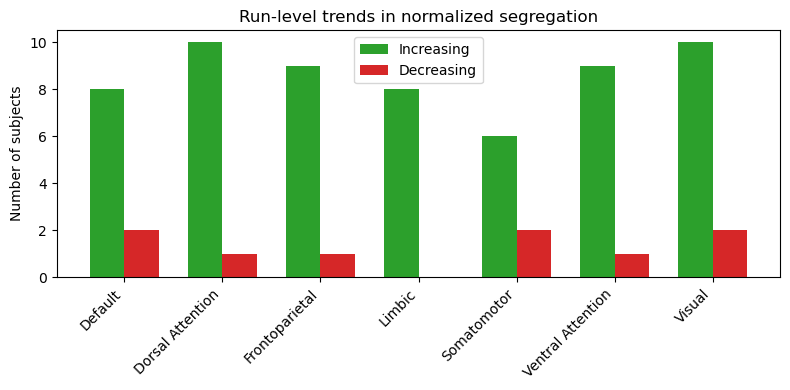

In [13]:
import matplotlib.pyplot as plt

run_norm = summary_runs[summary_runs["metric"] == "norm"].copy()

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(run_norm["network"]))
width = 0.35

ax.bar(x - width/2, run_norm["n_inc"], width, label="Increasing", color="tab:green")
ax.bar(x + width/2, run_norm["n_dec"], width, label="Decreasing", color="tab:red")

ax.set_xticks(x)
ax.set_xticklabels(run_norm["network"], rotation=45, ha="right")
ax.set_ylabel("Number of subjects")
ax.set_title("Run-level trends in normalized segregation")
ax.legend()
plt.tight_layout()
plt.show()

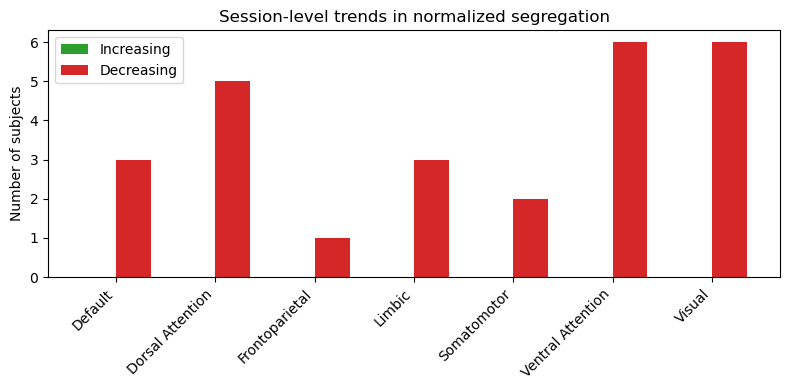

In [14]:
import matplotlib.pyplot as plt

# Filter session-level summary for normalized segregation ("norm")
sess_norm = summary_sess[summary_sess["metric"] == "int"].copy()

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(sess_norm["network"]))
width = 0.35

ax.bar(x - width/2, sess_norm["n_inc"], width,
       label="Increasing", color="tab:green")
ax.bar(x + width/2, sess_norm["n_dec"], width,
       label="Decreasing", color="tab:red")

ax.set_xticks(x)
ax.set_xticklabels(sess_norm["network"], rotation=45, ha="right")
ax.set_ylabel("Number of subjects")
ax.set_title("Session-level trends in normalized segregation")
ax.legend()
plt.tight_layout()
plt.show()

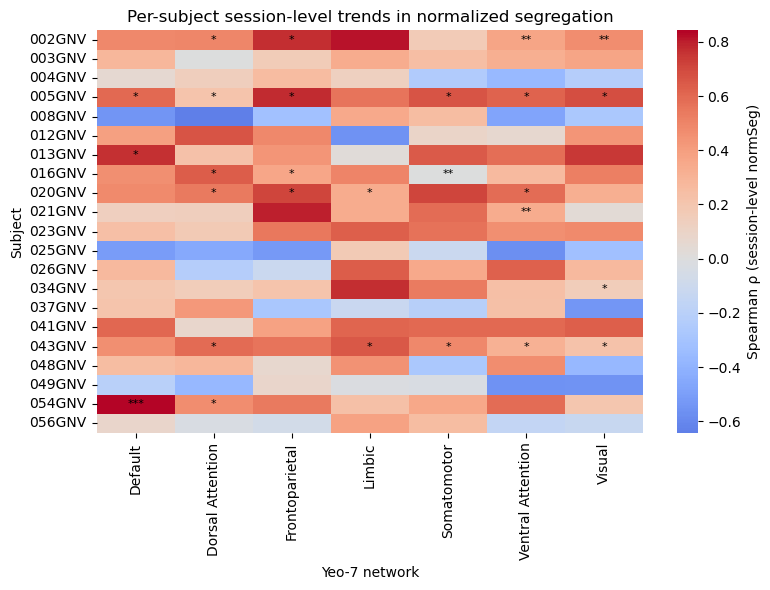

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot rho values
rho_sess_norm = df_subject_stats_sessions.pivot(
    index="subject", columns="network", values="rho_norm"
)

# Pivot stars (significance)
stars_sess_norm = df_subject_stats_sessions.pivot(
    index="subject", columns="network", values="norm_stars"
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    rho_sess_norm,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Spearman ρ (session-level normSeg)"}
)

# Overlay stars
for i, sid in enumerate(rho_sess_norm.index):
    for j, net in enumerate(rho_sess_norm.columns):
        s = stars_sess_norm.loc[sid, net]
        if s:
            ax.text(j + 0.5, i + 0.5, s,
                    ha="center", va="center", color="black", fontsize=8)

plt.title("Per-subject session-level trends in normalized segregation")
plt.ylabel("Subject")
plt.xlabel("Yeo-7 network")
plt.tight_layout()
plt.show()

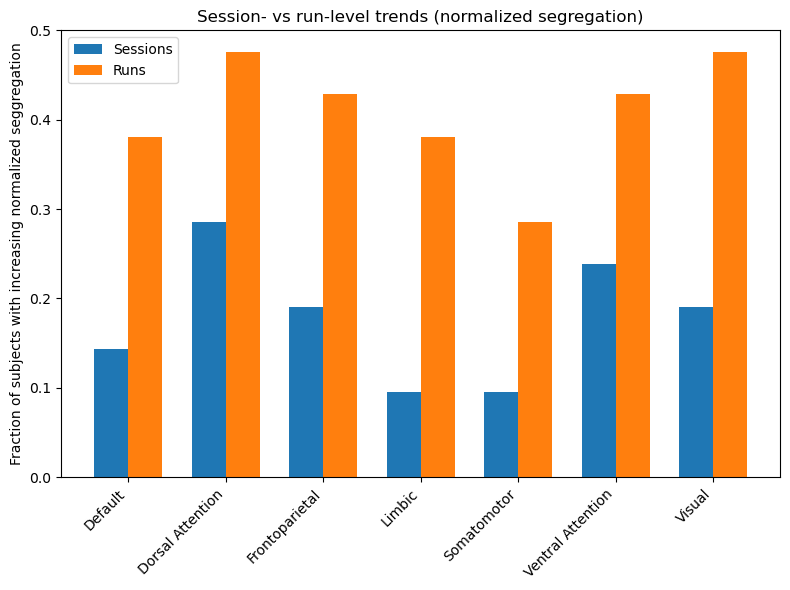

In [16]:
# Extract fractions
sess_norm = summary_sess[summary_sess["metric"] == "norm"].copy()
runs_norm = summary_runs[summary_runs["metric"] == "norm"].copy()

merged = sess_norm[["network", "frac_inc"]].merge(
    runs_norm[["network", "frac_inc"]],
    on="network",
    suffixes=("_sess", "_runs")
)

x = np.arange(len(merged["network"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, merged["frac_inc_sess"], width, label="Sessions")
ax.bar(x + width/2, merged["frac_inc_runs"], width, label="Runs")

ax.set_xticks(x)
ax.set_xticklabels(merged["network"], rotation=45, ha="right")
ax.set_ylabel("Fraction of subjects with increasing normalized seggregation")
ax.set_title("Session- vs run-level trends (normalized segregation)")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Example: run-level normalized segregation
df = df_subject_stats_runs.copy()

def sign_code(row):
    if row["p_norm_fdr"] >= 0.05 or np.isnan(row["rho_norm"]):
        return 0
    return 1 if row["rho_norm"] > 0 else -1

df["norm_code"] = df.apply(sign_code, axis=1)

# subject x network matrix of {-1, 0, +1}
pattern = df.pivot(index="subject", columns="network", values="norm_code")

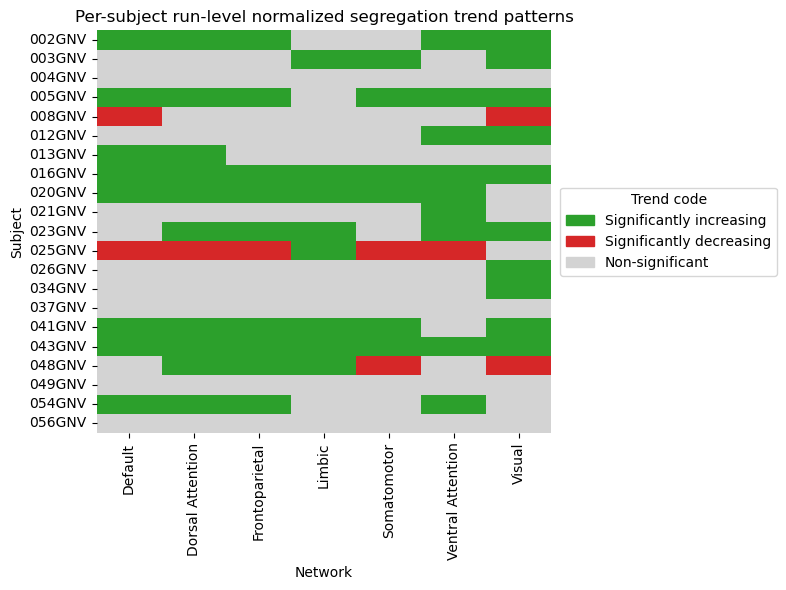

In [18]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pattern,
    cmap=sns.color_palette(["tab:red", "lightgrey", "tab:green"], as_cmap=True),
    vmin=-1, vmax=1,
    cbar=False  # no colorbar
)

plt.title("Per-subject run-level normalized segregation trend patterns")
plt.ylabel("Subject")
plt.xlabel("Network")

# Custom legend patches
green_patch = mpatches.Patch(color="tab:green", label="Significantly increasing")
red_patch   = mpatches.Patch(color="tab:red",   label="Significantly decreasing")
grey_patch  = mpatches.Patch(color="lightgrey", label="Non-significant")

# Place legend completely outside on the right
ax.legend(
    handles=[green_patch, red_patch, grey_patch],
    loc="center left",              # anchor left side of legend box
    bbox_to_anchor=(1.02, 0.5),     # x>1 puts it outside the axes
    borderaxespad=0.0,
    title="Trend code"
)

plt.tight_layout()
plt.show()

## 6e. Subject profiling

### i. Using significantly increasing, decreasing or no logic

In [19]:
from sklearn.cluster import AgglomerativeClustering

X = pattern.values  # subject x network, entries -1/0/+1
clust = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = clust.fit_predict(X)

pattern["cluster"] = labels

In [20]:
cluster_profiles = []
for c in sorted(pattern["cluster"].unique()):
    sub = pattern[pattern["cluster"] == c].drop(columns="cluster")
    prof = {
        "cluster": c,
        "n_subj": len(sub),
    }
    for net in sub.columns:
        prof[f"{net}_frac_inc"] = (sub[net] == 1).mean()
        prof[f"{net}_frac_dec"] = (sub[net] == -1).mean()
    cluster_profiles.append(prof)

cluster_profiles_df = pd.DataFrame(cluster_profiles)

In [21]:
# Simple table: subject and its cluster
subject_clusters = pattern["cluster"].reset_index()  # index -> column
subject_clusters.columns = ["subject", "cluster"]

for c in sorted(pattern["cluster"].unique()):
    subs = subject_clusters[subject_clusters["cluster"] == c]["subject"].tolist()
    print(f"Cluster {c} (n={len(subs)}): {subs}")

Cluster 0 (n=12): ['003GNV', '004GNV', '008GNV', '012GNV', '013GNV', '021GNV', '026GNV', '034GNV', '037GNV', '048GNV', '049GNV', '056GNV']
Cluster 1 (n=8): ['002GNV', '005GNV', '016GNV', '020GNV', '023GNV', '041GNV', '043GNV', '054GNV']
Cluster 2 (n=1): ['025GNV']


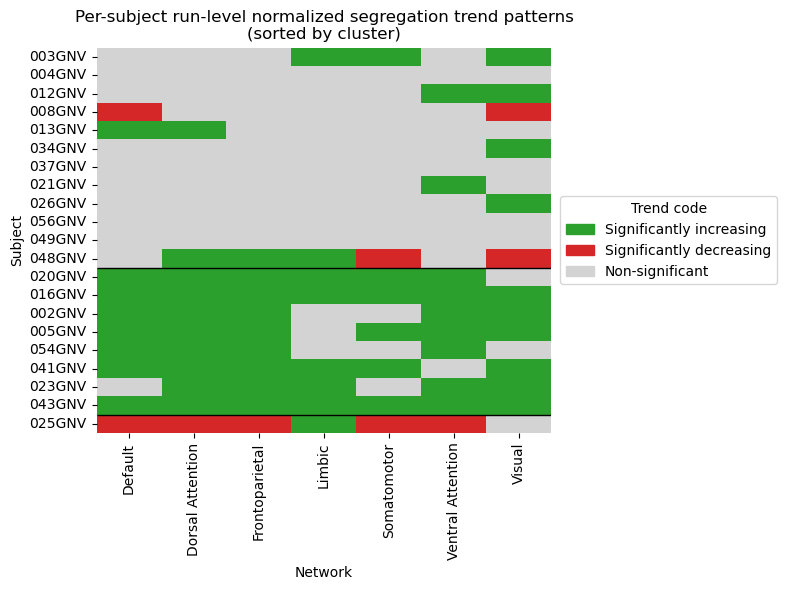

In [22]:
import matplotlib.patches as mpatches

# 1. Sort subjects by cluster (0, then 1, then 2)
pattern_sorted = pattern.sort_values("cluster")

# 2. Drop the cluster column for plotting
pattern_plot = pattern_sorted.drop(columns="cluster")

# indices where cluster changes
cluster_vals = pattern_sorted["cluster"].values
change_idx = [i for i in range(1, len(cluster_vals)) if cluster_vals[i] != cluster_vals[i-1]]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pattern_plot,
    cmap=sns.color_palette(["tab:red", "lightgrey", "tab:green"], as_cmap=True),
    vmin=-1, vmax=1,
    cbar=False
)

for i in change_idx:
    ax.hlines(i, *ax.get_xlim(), colors="black", linewidth=1)

plt.title("Per-subject run-level normalized segregation trend patterns\n(sorted by cluster)")
plt.ylabel("Subject")
plt.xlabel("Network")

# Custom legend patches
green_patch = mpatches.Patch(color="tab:green", label="Significantly increasing")
red_patch   = mpatches.Patch(color="tab:red",   label="Significantly decreasing")
grey_patch  = mpatches.Patch(color="lightgrey", label="Non-significant")



# Place legend completely outside on the right
ax.legend(
    handles=[green_patch, red_patch, grey_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    title="Trend code",
)

plt.tight_layout()
plt.show()

## 6f. Fine tuning the analysis

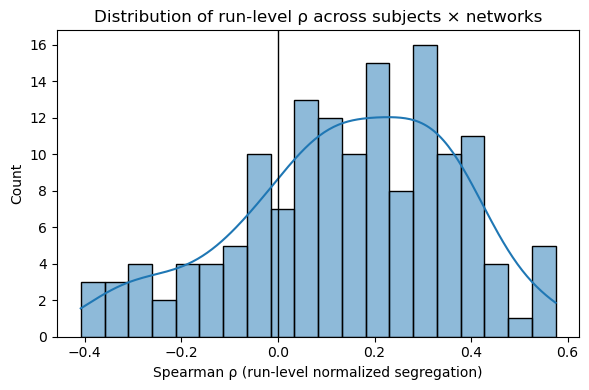

count    147.000000
mean       0.141840
std        0.222012
min       -0.408304
25%        0.019449
50%        0.158941
75%        0.311971
max        0.575157
Name: rho_norm, dtype: float64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract run-level normalized segregation rho values
rho_all = df_subject_stats_runs["rho_norm"].dropna()

plt.figure(figsize=(6, 4))
sns.histplot(rho_all, bins=20, kde=True)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman ρ (run-level normalized segregation)")
plt.ylabel("Count")
plt.title("Distribution of run-level ρ across subjects × networks")
plt.tight_layout()
plt.show()

print(rho_all.describe())

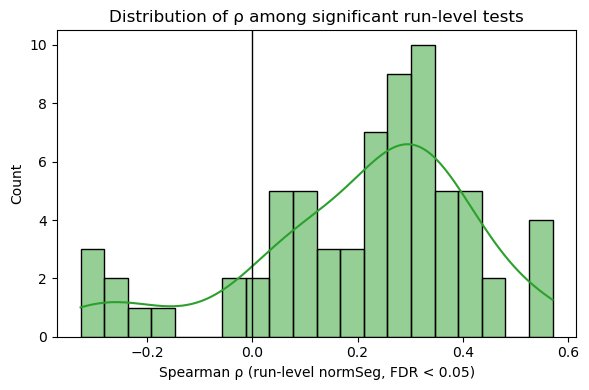

count    69.000000
mean      0.207144
std       0.211641
min      -0.325907
25%       0.100136
50%       0.259105
75%       0.333481
max       0.570537
Name: rho_norm, dtype: float64


In [24]:
alpha = 0.05

rho_sig = df_subject_stats_runs.loc[
    df_subject_stats_runs["p_norm_fdr"] < alpha, "rho_norm"
].dropna()

plt.figure(figsize=(6, 4))
sns.histplot(rho_sig, bins=20, kde=True, color="tab:green")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman ρ (run-level normSeg, FDR < 0.05)")
plt.ylabel("Count")
plt.title("Distribution of ρ among significant run-level tests")
plt.tight_layout()
plt.show()

print(rho_sig.describe())

In [25]:
# --- Stricter run-level coding for normalized segregation ---

# Copy to avoid accidental modification of earlier results
df_runs_strict = df_subject_stats_runs.copy()

alpha = 0.01    # FDR threshold (same as before)
rho_thr = 0.2   # effect-size threshold; you can tune (e.g. 0.3, 0.5)

def norm_code_strict_row(r):
    # require both FDR significance AND |rho_norm| >= rho_thr
    if pd.isna(r["rho_norm"]) or pd.isna(r["p_norm_fdr"]):
        return 0
    if r["p_norm_fdr"] >= alpha:
        return 0
    if abs(r["rho_norm"]) < rho_thr:
        return 0
    return 1 if r["rho_norm"] > 0 else -1

df_runs_strict["norm_code_strict"] = df_runs_strict.apply(norm_code_strict_row, axis=1)

# Subject x network matrix of strict codes
pattern_strict = df_runs_strict.pivot(
    index="subject", columns="network", values="norm_code_strict"
).fillna(0).astype(int)

pattern_strict

network,Default,Dorsal Attention,Frontoparietal,Limbic,Somatomotor,Ventral Attention,Visual
subject,,,,,,,
002GNV,1,1,1,0,0,0,0
003GNV,0,0,0,0,0,0,0
004GNV,0,0,0,0,0,0,0
005GNV,1,0,1,0,1,1,1
008GNV,-1,0,0,0,0,0,0
012GNV,0,0,0,0,0,0,1
013GNV,0,0,0,0,0,0,0
016GNV,1,1,1,1,0,0,1
020GNV,0,1,1,0,1,1,0


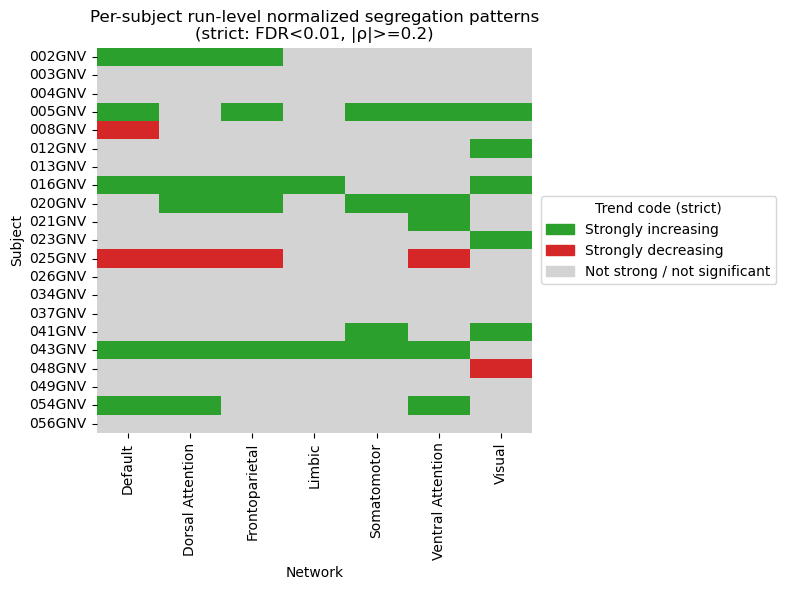

In [26]:
import seaborn as sns
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pattern_strict,
    cmap=sns.color_palette(["tab:red", "lightgrey", "tab:green"], as_cmap=True),
    vmin=-1, vmax=1,
    cbar=False,
)

plt.title(
    "Per-subject run-level normalized segregation patterns\n"
    f"(strict: FDR<{alpha}, |ρ|>={rho_thr})"
)
plt.ylabel("Subject")
plt.xlabel("Network")

green_patch = mpatches.Patch(color="tab:green", label="Strongly increasing")
red_patch   = mpatches.Patch(color="tab:red",   label="Strongly decreasing")
grey_patch  = mpatches.Patch(color="lightgrey", label="Not strong / not significant")

ax.legend(
    handles=[green_patch, red_patch, grey_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    title="Trend code (strict)",
)

plt.tight_layout()
plt.show()

In [27]:
from sklearn.cluster import AgglomerativeClustering

# pattern_strict: subject x network, entries -1/0/+1
pattern_strong = pattern_strict.copy()

X_strong = pattern_strong.values  # subject x network

clust_strong = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_strong = clust_strong.fit_predict(X_strong)

pattern_strong["cluster"] = labels_strong

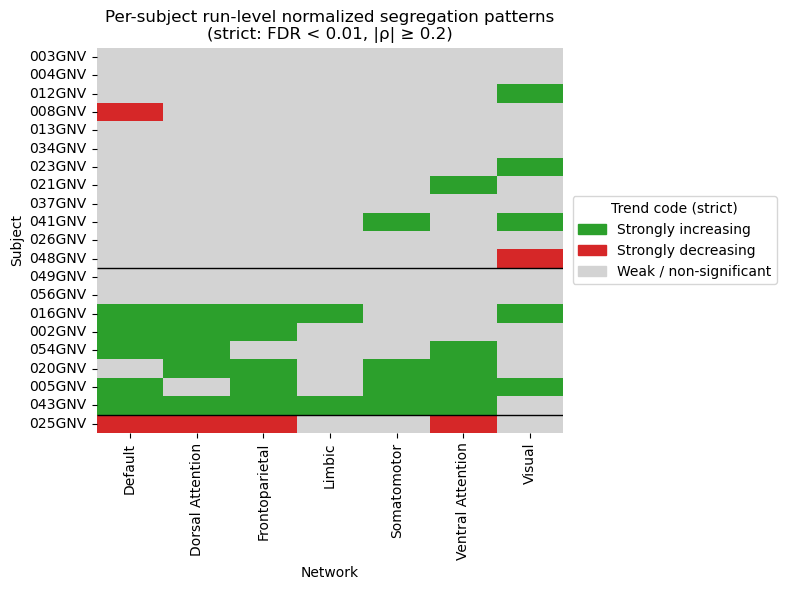

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# sort by cluster
pattern_strong_sorted = pattern_strong.sort_values("cluster")
pattern_strong_plot = pattern_strong_sorted.drop(columns="cluster")

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pattern_strong_plot,
    cmap=sns.color_palette(["tab:red", "lightgrey", "tab:green"], as_cmap=True),
    vmin=-1, vmax=1,
    cbar=False,
)

plt.title(
    "Per-subject run-level normalized segregation patterns\n"
    f"(strict: FDR < {alpha}, |ρ| ≥ {rho_thr})"
)
plt.ylabel("Subject")
plt.xlabel("Network")

green_patch = mpatches.Patch(color="tab:green", label="Strongly increasing")
red_patch   = mpatches.Patch(color="tab:red",   label="Strongly decreasing")
grey_patch  = mpatches.Patch(color="lightgrey", label="Weak / non-significant")

for i in change_idx:
    ax.hlines(i, *ax.get_xlim(), colors="black", linewidth=1)


ax.legend(
    handles=[green_patch, red_patch, grey_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    title="Trend code (strict)",
)

plt.tight_layout()
plt.show()